# accDM: aktualna mapa w osiach masy i frakcji

Mapa analogiczna do przesłanego rysunku: $x=\log_{10}(m_{\rm acc}/{\rm GeV})$,
$y=\log_{10}f_{\rm acc}$, skala koloru **0–6**, wartości **powyżej 6 — niebieskie**.
Pełna mapa obejmuje cały zakres bieżących manifestów, w tym rozszerzenie $m>10^{18}$.
Drugi rysunek pokazuje dokładnie stary kadr: $11\le x\le18$, $-3\le y\le0$.

**Uruchomienie:** umieść notebook w projekcie `lyalpha_one_loop` lub jego
podkatalogu, sprawdź ścieżki w następnej komórce i wybierz **Restart & Run All**.
Wymagane: Python ≥3.9, NumPy, pandas, SciPy, Matplotlib.
Notebook zawiera cały potrzebny kod; nie wymaga uruchamiania notebooków 06–09,
CLASS ani nowych fitów. Wczytuje bieżący bazowy CSV oraz ukończone JSON-y obu
kampanii low-ε. Jeśli aktualizujesz fity starej domeny, odśwież również bazowy CSV.

**Brakujące wartości są oszacowaniem, a nie wykonanym fitem.** W małych lukach
stosowana jest lokalna interpolacja/ciąg dalszy. Dla brakującego rogu
$\log_{10}m>18$, $\log_{10}f>-1$ zachowano scenariusz przesuniętego DCDM
z załączonego notebooka oraz zszycie z brzegami accDM. Po wyjściu poza zakres
szablonu domyślnie utrzymywana jest wartość na jego brzegu, również w ε.
Dlatego mapa może być wypełniona także tam, gdzie stara wersja pozostawiała luki.
Po pojawieniu się nowego poprawnie ukończonego fitu zastępuje on prognozę.

Normalizacja: $\Delta\chi^2\equiv\chi^2-\chi^2_{\rm ref}$, gdzie domyślnie
$\chi^2_{\rm ref}$ jest minimum **zaufanych, obliczonych punktów** w stabilnym
oknie poprzedniej analizy. To nie musi być globalne minimum całej siatki.
Prognozy nie zmieniają punktu odniesienia; ujemne wartości pozostają w eksporcie.
Notebook nie wyznacza poziomów ufności na podstawie uzupełnionych komórek.

Zapis: `runs/accdm/analysis_mass_fraction_completed_v1` — PNG/PDF pełnej mapy,
stary kadr, mapa pochodzenia wartości, CSV/NPZ z surowymi i uzupełnionymi liczbami,
diagnostyka scenariusza oraz JSON z ustawieniami i hashami wejść.


In [12]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
from scipy.spatial import cKDTree
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator, griddata

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)


def find_project_root():
    override = os.environ.get("ACCDM_PROJECT_ROOT")
    if override:
        return Path(override).expanduser().resolve()
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if ((candidate / "lyalpha_pt").is_dir()
                or (candidate / "runs/accdm").is_dir()):
            return candidate
    return start


def env_path(name, default):
    return Path(os.environ.get(name, str(default))).expanduser().resolve()


PROJECT_ROOT = find_project_root()  # można zastąpić przez Path('/.../lyalpha_one_loop')
BASE_ANALYSIS_DIR = env_path(
    "ACCDM_BASE_ANALYSIS_DIR",
    PROJECT_ROOT / "runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1",
)
OUTPUT_DIR = env_path(
    "ACCDM_NATIVE_OUTPUT_DIR",
    PROJECT_ROOT / "runs/accdm/analysis_mass_fraction_completed_v1",
)
# None = automatyczne wyszukanie tego samego CSV co w notebooku 07.
DCDM_PROFILE_OVERRIDE = os.environ.get("ACCDM_DCDM_PROFILE_CSV")
EXTENSION_CAMPAIGNS = [
    dict(label="loweps_low_q1001", region="low", momentum_bins=1001, priority=100,
         directory=env_path("ACCDM_LOWEPS_LOWF_CAMPAIGN",
             PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_lowf_q1001_v1")),
    dict(label="loweps_high_q5001", region="high", momentum_bins=5001, priority=100,
         directory=env_path("ACCDM_LOWEPS_HIGHF_CAMPAIGN",
             PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_highf_q5001_v1")),
]

# Najważniejsze pokrętła scenariusza.
SHIFT_QUERY_DEX = None        # None: kalibracja; +0.92 przesuwa widoczny DCDM W LEWO.
SHIFT_FALLBACK_DEX = 0.9196060713694787  # wynik zapisany w załączonym notebooku
SHIFT_BOUNDS = (-1.5, 1.5)
TEMPLATE_AMPLITUDE = 1.0      # 1 = zachowany kontrast Δχ²; to założenie, nie dopasowanie
TEMPLATE_OFFSET = 0.0         # opcjonalna zmiana poziomu daleko od brzegu
EPS_BLEND_DEX = 0.18          # szerokość zszycia ze starą domeną w log10 ε
GAMMA_BLEND_DEX = 0.18        # zszycie z ukończonym pasem f <= 0.1
SHIFT_SENSITIVITY_DEX = 0.20  # warianty, NIE przedział wiarygodności

# Jawna kontynuacja wartości na brzegu szablonu, nie dodatkowy fit.
TEMPLATE_GAMMA_OUTSIDE = "hold"       # "hold" lub "mask"; f=1 ma Gamma=+inf
TEMPLATE_EPSILON_OUTSIDE = "hold"     # wypełnia także masy poza zakresem epsilon DCDM
UNSUPPORTED_CORNER_POLICY = "local"  # "local" lub "mask", gdy szablon nadal daje NaN

ORIGINAL_MAX_LOGM = 18.0
TRANSITION_LOGF = -1.0
T_REFERENCE_GYR = 14.0
STABLE_LOGEPS_WINDOW = (-2.5, -2.0)
TRUST_REQUIRE_OPTIMIZER_SUCCESS = True
MIN_TRUSTED_BOUND_DISTANCE = 0.02
REFERENCE_CHI2_OVERRIDE = None  # liczba: ręcznie ustalony punkt odniesienia
REPAIR_KNOWN_OUTLIERS = True
# Naprawiaj tylko te SAME stare artefakty; poprawiony nowy fit ma pierwszeństwo.
KNOWN_OUTLIER_RAW_CHI2 = {
    (14.7142857142857, -1.375): 228.833338,
    (15.0, -1.375): 231.245070,
}
KNOWN_OUTLIER_MATCH_ATOL = 1e-4
KNOWN_LOWF_REPAIR_COORDS = (
    ((14.7142857142857, -1.375), (15.0, -1.375))
    if REPAIR_KNOWN_OUTLIERS else ()
)

# None = pełen zakres aktualnej siatki; stare granice są zapisane osobno.
PLOT_XLIM = None
PLOT_YLIM = None
LEGACY_XLIM = (11.0, 18.0)
LEGACY_YLIM = (-3.0, 0.0)
DISPLAY_DELTA_MAX = 6.0
PLOT_STYLE = "cells"          # "cells" jak przykład; "bilinear" dla gładszego koloru
PLOT_RESOLUTION = (700, 500)  # używane tylko przy PLOT_STYLE="bilinear"
SHOW_ESTIMATE_HATCH = False  # opcjonalne kreskowanie wszystkich uzupełnionych komórek
SHOW_CORNER_BOUNDARY = False
SAVE_LEGACY_CROP = True
RUN_SHIFT_SENSITIVITY = True
SHOW_SHIFT_SENSITIVITY = False
SAVE_OUTPUTS = os.environ.get("ACCDM_SAVE_OUTPUTS", "1") != "0"

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 110, "savefig.dpi": 250,
    "axes.spines.top": True, "axes.spines.right": True,
})
assert EPS_BLEND_DEX > 0 and GAMMA_BLEND_DEX > 0
assert TEMPLATE_AMPLITUDE > 0
assert TEMPLATE_GAMMA_OUTSIDE in {"hold", "mask"}
assert TEMPLATE_EPSILON_OUTSIDE in {"hold", "mask"}
assert UNSUPPORTED_CORNER_POLICY in {"local", "mask"}
assert PLOT_STYLE in {"cells", "bilinear"}
assert DISPLAY_DELTA_MAX > 0
print("Project:", PROJECT_ROOT)
print("Output :", OUTPUT_DIR)


Project: /home/2/ks405818/Master/lyalpha_one_loop
Output : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_mass_fraction_completed_v1


## 1. Wczytanie aktualnych wyników

Baza: `updated_hybrid_sampled_profile_likelihood.csv`.
Rozszerzenia: `accdm_scan_loweps_lowf_q1001_v1` i `accdm_scan_loweps_highf_q5001_v1`.
Potrzebny jest plik fitu z poprawnym χ², znacznik `fit/*.done.json` oraz brak
znacznika `fit/*.failed.json`. Nowsza kampania ma pierwszeństwo w powtórzonych
współrzędnych. Brak wymaganego manifestu zatrzymuje wykonanie z czytelną ścieżką.
Diagnozy optymalizatora służą do wyboru kotwic prognozy; ukończone fity o gorszych
diagnozach nadal są zachowane i oznaczone na mapie pochodzenia.


In [13]:
def active_mask(frame):
    if "active" not in frame:
        return np.ones(len(frame), dtype=bool)
    return frame["active"].astype(str).str.strip().str.lower().isin({"true", "1", "1.0", "yes"})


def coordinate_key(logm, logf):
    return f"{float(logm):.10f}|{float(logf):.10f}"


def fit_summary(path):
    payload = json.loads(path.read_text(encoding="utf-8"))
    loop = payload.get("fits", {}).get("one_loop")
    if loop is None or not np.isfinite(float(loop.get("chi2", np.nan))):
        return None
    diagnostics = loop.get("boundary_diagnostics", [])
    nearest = None
    if diagnostics:
        nearest = min(
            diagnostics,
            key=lambda item: float(item["relative_distance_to_nearest_bound"]),
        )
    return {
        "chi2_one_loop": float(loop["chi2"]),
        "chi2_per_dof": float(loop.get("chi2_per_dof", np.nan)),
        "optimizer_success": str(loop.get("optimizer_success", False)).strip().lower()
            in {"true", "1", "1.0", "yes"},
        "minimum_bound_distance": (
            float(nearest["relative_distance_to_nearest_bound"])
            if nearest is not None else np.nan
        ),
        "minimum_bound_parameter": nearest["parameter"] if nearest is not None else None,
    }


def load_extension_campaign(source):
    directory = Path(source["directory"])
    manifest_path = directory / "manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing extension manifest: {manifest_path}")
    manifest = pd.read_csv(manifest_path)
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    for record in manifest.to_dict(orient="records"):
        point_id = str(record["point_id"])
        fit_path = directory / "fits" / f"{point_id}.json"
        fit_done = directory / "status/fit" / f"{point_id}.done.json"
        fit_failed = directory / "status/fit" / f"{point_id}.failed.json"
        theory_path = directory / "theory" / f"{point_id}.npz"
        theory_done = directory / "status/theory" / f"{point_id}.done.json"
        theory_failed = directory / "status/theory" / f"{point_id}.failed.json"
        fit_has_failure_marker = fit_failed.is_file()
        theory_has_failure_marker = theory_failed.is_file()
        row = {
            **record,
            "coordinate_key": coordinate_key(record["log10m_acc"], record["log10f_acc"]),
            "expected_region": source["region"],
            "source_label": source["label"],
            "source_directory": str(directory),
            "source_priority": int(source["priority"]),
            "momentum_bins": int(source["momentum_bins"]),
            "theory_complete": (
                theory_path.is_file() and theory_done.is_file()
                and not theory_has_failure_marker
            ),
            "theory_failed": theory_has_failure_marker,
            "fit_complete": (
                fit_path.is_file() and fit_done.is_file()
                and not fit_has_failure_marker
            ),
            "fit_failed": fit_has_failure_marker,
            "chi2_one_loop": np.nan,
        }
        if row["fit_complete"]:
            try:
                parsed = fit_summary(fit_path)
            except (ValueError, TypeError, KeyError, OSError) as exc:
                warnings.warn(f"Skipping invalid fit {fit_path}: {exc}")
                parsed = None
            if parsed is not None:
                row.update(parsed)
            else:
                row["fit_complete"] = False
                row["fit_failed"] = True
        row["missing_reason"] = (
            "fit failed" if row["fit_failed"] else
            "theory failed" if row["theory_failed"] else
            "fit pending or missing" if row["theory_complete"] else
            "theory active, pending, or absent"
        )
        rows.append(row)
    return pd.DataFrame(rows)


base_sampled_path = BASE_ANALYSIS_DIR / "updated_hybrid_sampled_profile_likelihood.csv"
base_missing_path = BASE_ANALYSIS_DIR / "updated_hybrid_cross_markers.csv"
summary_path = BASE_ANALYSIS_DIR / "updated_hybrid_analysis_summary.json"
if not base_sampled_path.is_file():
    raise FileNotFoundError(base_sampled_path)

base_sampled = pd.read_csv(base_sampled_path)
base_missing = (
    pd.read_csv(base_missing_path)
    if base_missing_path.is_file()
    else pd.DataFrame(columns=["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"])
)
required = {"log10m_acc", "log10f_acc", "chi2_one_loop"}
missing_columns = required - set(base_sampled.columns)
if missing_columns:
    raise KeyError(f"Base accDM table lacks columns: {sorted(missing_columns)}")

analysis_summary = (
    json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.is_file() else {}
)
LCDM_ONE_LOOP_CHI2 = float(analysis_summary.get("lcdm_reference_chi2", 193.105787))

base_sampled = base_sampled.loc[np.isfinite(base_sampled["chi2_one_loop"])].copy()
if "fit_complete" in base_sampled:
    complete = base_sampled["fit_complete"].astype(str).str.lower().isin({"true", "1", "1.0", "yes"})
    base_sampled = base_sampled.loc[complete].copy()
if "fit_failed" in base_sampled:
    failed = base_sampled["fit_failed"].astype(str).str.lower().isin({"true", "1", "1.0", "yes"})
    base_sampled = base_sampled.loc[~failed].copy()
base_sampled[["log10m_acc", "log10f_acc"]] = base_sampled[["log10m_acc", "log10f_acc"]].round(10)
base_sampled["coordinate_key"] = [
    coordinate_key(m, f) for m, f in zip(base_sampled["log10m_acc"], base_sampled["log10f_acc"])
]
base_sampled["expected_region"] = np.where(
    base_sampled["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
)
base_sampled["source_priority"] = 0
if "source_label" not in base_sampled:
    base_sampled["source_label"] = "validated_hybrid_base"
if "momentum_bins" not in base_sampled:
    base_sampled["momentum_bins"] = np.where(
        base_sampled["log10f_acc"] <= TRANSITION_LOGF, 1001, 5001
    )

base_missing[["log10m_acc", "log10f_acc"]] = base_missing[["log10m_acc", "log10f_acc"]].astype(float).round(10)
if True:  # również pusta tabela ma potrzebne kolumny
    base_missing["coordinate_key"] = [
        coordinate_key(m, f) for m, f in zip(base_missing["log10m_acc"], base_missing["log10f_acc"])
    ]
    base_missing["expected_region"] = np.where(
        base_missing["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
    )

extension_frames = [load_extension_campaign(source) for source in EXTENSION_CAMPAIGNS]
extension_inventory = pd.concat(extension_frames, ignore_index=True, sort=False)
extension_inventory[["log10m_acc", "log10f_acc"]] = extension_inventory[["log10m_acc", "log10f_acc"]].round(10)
extension_completed = extension_inventory.loc[np.isfinite(extension_inventory["chi2_one_loop"])].copy()

sampled = pd.concat([base_sampled, extension_completed], ignore_index=True, sort=False)
sampled = (
    sampled.sort_values(["coordinate_key", "source_priority", "source_label"])
    .drop_duplicates("coordinate_key", keep="last")
    .copy()
)

if "optimizer_success" in sampled:
    optimizer_success = sampled["optimizer_success"]
    if optimizer_success.dtype != bool:
        optimizer_success = optimizer_success.astype(str).str.strip().str.lower().isin(
            {"true", "1", "1.0", "yes"}
        )
    else:
        optimizer_success = optimizer_success.fillna(False)
else:
    optimizer_success = pd.Series(True, index=sampled.index)

bound_distance = pd.to_numeric(
    sampled.get("minimum_bound_distance", pd.Series(np.nan, index=sampled.index)),
    errors="coerce",
)
trusted_for_forecast = pd.Series(True, index=sampled.index)
if TRUST_REQUIRE_OPTIMIZER_SUCCESS:
    trusted_for_forecast &= optimizer_success
# Brak diagnostyki granic nie jest automatycznie porażką. Jeżeli diagnostyka jest
# dostępna, odrzucamy tylko rozwiązania rzeczywiście przyklejone do ściany boxa.
trusted_for_forecast &= bound_distance.isna() | (
    bound_distance >= MIN_TRUSTED_BOUND_DISTANCE
)
configured_repair_keys = set()
for logm, logf in KNOWN_LOWF_REPAIR_COORDS:
    key = coordinate_key(logm, logf)
    match = sampled.loc[sampled.coordinate_key == key, "chi2_one_loop"]
    old_value = KNOWN_OUTLIER_RAW_CHI2[(logm, logf)]
    if len(match) and abs(float(match.iloc[0])-old_value) <= KNOWN_OUTLIER_MATCH_ATOL:
        configured_repair_keys.add(key)
trusted_for_forecast &= ~sampled["coordinate_key"].isin(configured_repair_keys)
sampled["trusted_for_forecast"] = trusted_for_forecast.astype(bool)

base_expected = pd.concat([
    base_sampled[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
    base_missing[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
], ignore_index=True)
extension_expected = extension_inventory[
    ["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]
]
expected_points = (
    pd.concat([base_expected, extension_expected], ignore_index=True)
    .drop_duplicates("coordinate_key", keep="last")
    .sort_values(["log10f_acc", "log10m_acc"])
    .reset_index(drop=True)
)
missing_now = expected_points.loc[
    ~expected_points["coordinate_key"].isin(sampled["coordinate_key"])
].copy()

extension_status = extension_inventory.groupby("source_label").agg(
    planned=("point_id", "size"),
    theory_complete=("theory_complete", "sum"),
    theory_failed=("theory_failed", "sum"),
    fit_complete=("fit_complete", "sum"),
    fit_failed=("fit_failed", "sum"),
    fitted=("chi2_one_loop", "count"),
)
extension_status["coverage"] = extension_status["fitted"] / extension_status["planned"]

print("Validated base points   :", len(base_sampled))
print("Completed extension fits:", len(extension_completed))
print("Expected full grid cells:", len(expected_points))
print("Missing now             :", len(missing_now))
print("Trusted forecast anchors:", int(sampled["trusted_for_forecast"].sum()),
      "/", len(sampled))
display(extension_status)


Validated base points   : 1425
Completed extension fits: 175
Expected full grid cells: 1740
Missing now             : 140
Trusted forecast anchors: 1578 / 1600


,planned,theory_complete,theory_failed,fit_complete,fit_failed,fitted,coverage
source_label,,,,,,,
loweps_high_q5001,120,8,1,8,0,8,0.066667
loweps_low_q1001,170,167,3,167,0,167,0.982353


## 2. Punkt odniesienia i współrzędne pomocnicze

Transformacja do efektywnych Γ i ε jest używana **wyłącznie do prognozy DCDM**.
Na końcowym rysunku pozostają natywne masa i frakcja, więc wiersz $f=1$ jest
normalnym skończonym położeniem $\log_{10}f=0$. W prognozie odpowiada mu
$\Gamma\to\infty$; użycie brzegu szablonu jest wtedy oznaczone jako kontynuacja.


In [14]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = np.sqrt(eta * (eta + 2.0))
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


sampled["log10_epsilon_eff"] = np.log10(
    epsilon_effective_from_log10_mass(sampled["log10m_acc"])
)
sampled["log10_gamma_eff"] = np.log10(
    gamma_effective_from_log10_fraction(sampled["log10f_acc"])
)

repair_keys = configured_repair_keys.copy()
stable_candidates = sampled.loc[
    sampled["log10_epsilon_eff"].between(*STABLE_LOGEPS_WINDOW)
    & (sampled["log10f_acc"] <= TRANSITION_LOGF + 1e-12)
    & ~sampled["coordinate_key"].isin(repair_keys)
    & sampled["trusted_for_forecast"]
].copy()
if stable_candidates.empty:
    raise RuntimeError("No measured low-f point lies in the stable epsilon window.")

stable_reference = stable_candidates.loc[stable_candidates["chi2_one_loop"].idxmin()]
REFERENCE_CHI2 = (
    float(stable_reference["chi2_one_loop"]) if REFERENCE_CHI2_OVERRIDE is None
    else float(REFERENCE_CHI2_OVERRIDE)
)
if not np.isfinite(REFERENCE_CHI2):
    raise ValueError("REFERENCE_CHI2 must be finite.")
REFERENCE_METHOD = "stable_measured_minimum" if REFERENCE_CHI2_OVERRIDE is None else "manual"
print("Reference method:", REFERENCE_METHOD)

print("Stable measured reference")
print(" point  :", stable_reference.get("point_id", stable_reference["coordinate_key"]))
print(f" logm   : {stable_reference['log10m_acc']:.6f}")
print(f" logf   : {stable_reference['log10f_acc']:.6f}")
print(f" logeps : {stable_reference['log10_epsilon_eff']:.6f}")
print(f" chi2   : {REFERENCE_CHI2:.9f}")
print(f" vs LCDM: {REFERENCE_CHI2 - LCDM_ONE_LOOP_CHI2:+.9f}")


Reference method: stable_measured_minimum
Stable measured reference
 point  : accdm_logm15p7142857142857_logfm1p3
 logm   : 15.714286
 logf   : -1.300000
 logeps : -2.209324
 chi2   : 188.986412635
 vs LCDM: -4.210197964


## 3. Rzeczywisty szablon DCDM

Wczytywany jest CSV DCDM z tego samego projektu co w załączniku. Nie jest
odtwarzany ze zrzutu ekranu. Jego minimum jest normalizowane osobno; przenoszony
jest kształt Δχ². Gdy ścieżka nie zostanie znaleziona, ustaw `DCDM_PROFILE_OVERRIDE`.


In [15]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_sorted_strings(values):
    payload = "\n".join(sorted(str(value) for value in values)).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def locate_dcdm_profile():
    override = DCDM_PROFILE_OVERRIDE
    candidates = []
    if override:
        explicit = Path(override).expanduser().resolve()
        if not explicit.is_file():
            raise FileNotFoundError(f"DCDM_PROFILE_OVERRIDE does not exist: {explicit}")
        return explicit
    candidates.extend([
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv",
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/dcdm_fit_master_table.csv",
        PROJECT_ROOT / "plots_dcdm/dcdm_fit_master_table.csv",
        PROJECT_ROOT.parent / "jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv",
        Path("/home/2/ks405818/Master/jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv"),
    ])
    for path in candidates:
        if path.is_file():
            return path.resolve()
    for pattern in (
        "runs/dcdm/**/campaign_profile_likelihood.csv",
        "runs/dcdm/**/dcdm_fit_master_table.csv",
    ):
        matches = sorted(PROJECT_ROOT.glob(pattern))
        if matches:
            if len(matches) > 1:
                raise RuntimeError("Multiple DCDM profiles found; set DCDM_PROFILE_OVERRIDE: "
                                   + ", ".join(map(str, matches)))
            return matches[0].resolve()
    return None


def choose_column(frame, candidates, description):
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"Cannot identify {description}; tried {candidates}.")


DCDM_PROFILE_CSV = locate_dcdm_profile()
DCDM_AVAILABLE = DCDM_PROFILE_CSV is not None

if not DCDM_AVAILABLE:
    raise FileNotFoundError(
        "DCDM profile table was not found. Set ACCDM_DCDM_PROFILE_CSV to "
        "campaign_profile_likelihood.csv (or dcdm_fit_master_table.csv)."
    )

if DCDM_AVAILABLE:
    dcdm_raw = pd.read_csv(DCDM_PROFILE_CSV)
    gamma_column = choose_column(
        dcdm_raw,
        ["log10_gamma_gyr_inverse", "log10_Gamma_Gyr_inv", "log10_gamma_gyr_inv"],
        "DCDM log10 Gamma column",
    )
    epsilon_column = choose_column(dcdm_raw, ["log10_epsilon"], "DCDM log10 epsilon column")
    chi2_column = choose_column(dcdm_raw, ["chi2_one_loop", "chi2_min"], "DCDM chi2 column")
    if "has_fit" in dcdm_raw:
        keep = dcdm_raw["has_fit"].astype(str).str.lower().isin({"true", "1", "1.0", "yes"})
        dcdm_raw = dcdm_raw.loc[keep].copy()
    dcdm = dcdm_raw.rename(columns={
        gamma_column: "log10_gamma",
        epsilon_column: "log10_epsilon",
        chi2_column: "chi2",
    })
    dcdm = dcdm.loc[
        np.isfinite(dcdm["log10_gamma"])
        & np.isfinite(dcdm["log10_epsilon"])
        & np.isfinite(dcdm["chi2"])
    ].copy()
    dcdm["delta_chi2"] = dcdm["chi2"] - float(dcdm["chi2"].min())
    dcdm_gamma_axis = np.sort(dcdm["log10_gamma"].unique())
    dcdm_epsilon_axis = np.sort(dcdm["log10_epsilon"].unique())
    if len(dcdm_gamma_axis) < 2 or len(dcdm_epsilon_axis) < 2:
        raise RuntimeError("DCDM profile must span at least two Gamma and epsilon values.")
    dcdm_grid = dcdm.pivot_table(
        index="log10_epsilon", columns="log10_gamma", values="delta_chi2", aggfunc="median"
    ).reindex(index=dcdm_epsilon_axis, columns=dcdm_gamma_axis).to_numpy(dtype=float)
    dcdm_unique = dcdm.groupby(
        ["log10_epsilon", "log10_gamma"], as_index=False
    )["delta_chi2"].median()
    # Scattered linear interpolation returns NaN outside the convex hull. We do not
    # patch unsupported DCDM regions with nearest-neighbour values.
    dcdm_interpolator = LinearNDInterpolator(
        np.column_stack([
            dcdm_unique["log10_epsilon"], dcdm_unique["log10_gamma"]
        ]),
        dcdm_unique["delta_chi2"].to_numpy(dtype=float),
        fill_value=np.nan,
    )
    DCDM_FILE_HASH = sha256_file(DCDM_PROFILE_CSV)
    print("DCDM profile:", DCDM_PROFILE_CSV)
    print("DCDM domain : gamma", (dcdm_gamma_axis.min(), dcdm_gamma_axis.max()),
          "epsilon", (dcdm_epsilon_axis.min(), dcdm_epsilon_axis.max()))
else:
    dcdm_raw = dcdm = pd.DataFrame()
    dcdm_gamma_axis = dcdm_epsilon_axis = np.array([], dtype=float)
    dcdm_grid = None
    dcdm_interpolator = None
    DCDM_FILE_HASH = "local-only"
    warnings.warn("DCDM unavailable: using local-only forecast by explicit request.")


DCDM profile: /home/2/ks405818/Master/lyalpha_one_loop/runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv
DCDM domain : gamma (-3.0, -0.0) epsilon (-4.0, -0.3010299956639812)


## 4. Luki w siatce i dwie odziedziczone naprawy

Dwie znane stare wartości χ² ≈228.833338 i 231.245070 przy $\log_{10}f=-1.375$
mogą zostać zastąpione lokalną estymacją. Naprawa działa **tylko gdy aktualna
wartość zgadza się ze starym artefaktem**; nowy fit w tym samym punkcie pozostaje
zachowany. Opcję można wyłączyć przez `REPAIR_KNOWN_OUTLIERS=False`.

Pozostałe luki są wypełniane liniowo z zaufanych obliczonych kotwic, osobno dla
pasów $f\le0.1$ i $f>0.1$. Poza ich otoczką wypukłą używana jest wartość
najbliższej kotwicy w jednostkach typowego kroku siatki. Te dwa sposoby są
oznaczone osobno. Nie stosuje się wygładzania ani filtrowania gotowych fitów.


In [16]:
x_grid = np.sort(expected_points["log10m_acc"].unique())
y_grid = np.sort(expected_points["log10f_acc"].unique())
chi_raw_grid = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="chi2_one_loop", aggfunc="last"
).reindex(index=y_grid, columns=x_grid).to_numpy(dtype=float)
trusted_mask_table = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="trusted_for_forecast", aggfunc="last"
).reindex(index=y_grid, columns=x_grid)
trusted_mask_grid = trusted_mask_table.eq(True).to_numpy(dtype=bool)

low_rows = y_grid <= TRANSITION_LOGF + 1e-12
high_rows = ~low_rows
chi_working = chi_raw_grid.copy()
repair_audit = []
repair_mask = np.zeros_like(chi_working, dtype=bool)


def grid_index(logm, logf, tolerance=1e-8):
    j = int(np.argmin(np.abs(x_grid - float(logm))))
    i = int(np.argmin(np.abs(y_grid - float(logf))))
    if abs(x_grid[j] - float(logm)) > tolerance or abs(y_grid[i] - float(logf)) > tolerance:
        return None
    return i, j


for logm, logf in KNOWN_LOWF_REPAIR_COORDS:
    index = grid_index(logm, logf)
    if index is None:
        warnings.warn(f"Configured low-f repair cell {(logm, logf)} is not on this grid.")
        continue
    i, j = index
    raw_value = chi_working[i, j]
    if coordinate_key(logm, logf) not in configured_repair_keys:
        print(f"Repair skipped at {(logm, logf)}: no matching old artifact.")
        continue
    repair_audit.append({
        "coordinate_key": coordinate_key(logm, logf),
        "log10m_acc": float(logm),
        "log10f_acc": float(logf),
        "raw_chi2": float(raw_value) if np.isfinite(raw_value) else np.nan,
    })
    chi_working[i, j] = np.nan
    repair_mask[i, j] = True


def linear_axis_estimate(array, i, j, axis, allowed_rows):
    if axis == 1:
        negative = [(i, jj) for jj in range(j - 1, -1, -1)]
        positive = [(i, jj) for jj in range(j + 1, array.shape[1])]
        coordinate = x_grid
        target = x_grid[j]
    else:
        negative = [(ii, j) for ii in range(i - 1, -1, -1) if allowed_rows[ii]]
        positive = [(ii, j) for ii in range(i + 1, array.shape[0]) if allowed_rows[ii]]
        coordinate = y_grid
        target = y_grid[i]
    left = next(((ii, jj) for ii, jj in negative if np.isfinite(array[ii, jj])), None)
    right = next(((ii, jj) for ii, jj in positive if np.isfinite(array[ii, jj])), None)
    if left is None or right is None:
        return np.nan, []
    li, lj = left
    ri, rj = right
    c0 = coordinate[lj] if axis == 1 else coordinate[li]
    c1 = coordinate[rj] if axis == 1 else coordinate[ri]
    fraction = (target - c0) / (c1 - c0)
    value = array[li, lj] + fraction * (array[ri, rj] - array[li, lj])
    return float(value), [float(array[li, lj]), float(array[ri, rj])]


repair_source = chi_working.copy()
repair_updates = []
for entry in repair_audit:
    i, j = grid_index(entry["log10m_acc"], entry["log10f_acc"])
    row_est, row_values = linear_axis_estimate(repair_source, i, j, 1, low_rows)
    col_est, col_values = linear_axis_estimate(repair_source, i, j, 0, low_rows)
    estimates = [value for value in (row_est, col_est) if np.isfinite(value)]
    neighbours = row_values + col_values
    if not estimates or not neighbours:
        raise RuntimeError(f"Cannot locally repair {entry['coordinate_key']}.")
    repaired = float(np.mean(estimates))
    repaired = float(np.clip(repaired, min(neighbours), max(neighbours)))
    repair_updates.append((i, j, repaired))
    entry.update({
        "row_estimate": row_est,
        "column_estimate": col_est,
        "repaired_chi2": repaired,
        "method": "bounded_mean_of_linear_row_and_column_interpolants",
    })

for i, j, repaired in repair_updates:
    chi_working[i, j] = repaired

repair_audit = pd.DataFrame(repair_audit)
trusted_chi_grid = np.where(trusted_mask_grid, chi_working, np.nan)



local_fill_kind = np.full(chi_raw_grid.shape, "", dtype=object)


def fill_region_from_anchors(array, row_mask):
    filled = np.asarray(array, float).copy()
    target = row_mask[:, None] & ~np.isfinite(filled)
    if not target.any():
        return filled
    anchor = row_mask[:, None] & np.isfinite(filled) & trusted_mask_grid
    if not anchor.any():
        raise RuntimeError("No trusted completed anchors in a fraction band.")
    yy, xx = np.meshgrid(y_grid, x_grid, indexing="ij")
    scale = np.array([np.median(np.diff(y_grid[row_mask])), np.median(np.diff(x_grid))])
    if not np.isfinite(scale).all() or (scale <= 0).any():
        raise RuntimeError("Each fraction band must contain at least two grid rows.")
    points = np.column_stack([yy[anchor], xx[anchor]]) / scale
    query = np.column_stack([yy[target], xx[target]]) / scale
    values = filled[anchor]
    if len(points) >= 3 and np.linalg.matrix_rank(points-points.mean(axis=0)) >= 2:
        linear = LinearNDInterpolator(points, values, fill_value=np.nan)(query)
    else:
        linear = np.full(len(query), np.nan)
    good = np.isfinite(linear)
    nearest = cKDTree(points).query(query)[1]
    filled[target] = np.where(good, linear, values[nearest])
    local_fill_kind[target] = np.where(good, "local_interpolation", "local_boundary_hold")
    return filled


chi_local_grid = fill_region_from_anchors(chi_working, low_rows)
chi_local_grid = fill_region_from_anchors(chi_local_grid, high_rows)
if not np.isfinite(chi_local_grid).all():
    raise RuntimeError("Local completion left non-finite cells.")
print("Explicit repairs:", len(repair_audit))
display(repair_audit)
display(pd.Series(local_fill_kind[local_fill_kind != ""]).value_counts().rename("cells"))


Explicit repairs: 2


,coordinate_key,log10m_acc,log10f_acc,raw_chi2,row_estimate,column_estimate,repaired_chi2,method
0,14.7142857143|-1.3750000000,14.714286,-1.375,228.833338,192.535149,191.940452,192.237801,bounded_mean_of_linear_row_and_column_interpol...
1,15.0000000000|-1.3750000000,15.000000,-1.375,231.245070,193.228197,193.758585,193.493391,bounded_mean_of_linear_row_and_column_interpol...


local_interpolation    116
local_boundary_hold     24
Name: cells, dtype: int64

## 5. Kalibracja przesunięcia na ukończonych punktach

Zachowany algorytm dopasowuje ostatnie rosnące przejścia przez pomocniczy poziom
Δχ²=5.991 w starej domenie. Nie używa uzupełnionych komórek. `SHIFT_QUERY_DEX=None`
oznacza ponowną kalibrację; przy zbyt małej liczbie przekrojów używany jest jawny
fallback zapisany w załączonej analizie. To parametr scenariusza, nie pomiar
równoważności fizycznej DCDM i accDM.


In [17]:
def smootherstep01(value):
    t = np.clip(np.asarray(value, dtype=float), 0, 1)
    return t**3 * (10 - 15*t + 6*t*t)



def dcdm_shape(loggamma, logeps, shift=0.0, gamma_outside="mask", epsilon_outside="mask"):
    g, e = np.broadcast_arrays(np.asarray(loggamma, float), np.asarray(logeps, float))
    query_g = g + shift
    inside_gamma = (np.isfinite(query_g) & (query_g >= dcdm_gamma_axis.min())
                    & (query_g <= dcdm_gamma_axis.max()))
    inside_eps = (np.isfinite(e) & (e >= dcdm_epsilon_axis.min())
                  & (e <= dcdm_epsilon_axis.max()))
    if gamma_outside == "hold":
        query_g = np.clip(query_g, dcdm_gamma_axis.min(), dcdm_gamma_axis.max())
        gamma_ok = np.isfinite(query_g)
    else:
        gamma_ok = inside_gamma
    if epsilon_outside == "hold":
        query_e = np.clip(e, dcdm_epsilon_axis.min(), dcdm_epsilon_axis.max())
        epsilon_ok = np.isfinite(query_e)
    else:
        query_e, epsilon_ok = e, inside_eps
    ok = gamma_ok & epsilon_ok
    result = np.full(g.shape, np.nan)
    result[ok] = dcdm_interpolator(np.column_stack([query_e[ok], query_g[ok]]))
    supported = inside_gamma & inside_eps & np.isfinite(result)
    return result, supported


def last_upward_crossing(x, z, level=5.991, max_gap=0.55):
    ok = np.isfinite(x) & np.isfinite(z)
    x, z = np.asarray(x)[ok], np.asarray(z)[ok]
    order = np.argsort(x)
    x, z = x[order], z[order]
    if len(x) < 3:
        return np.nan
    hit = np.flatnonzero((z[:-1] < level) & (z[1:] >= level) & (np.diff(x) <= max_gap))
    if not len(hit):
        return np.nan
    i = hit[-1]
    return float(x[i] + (level-z[i])/(z[i+1]-z[i]) * (x[i+1]-x[i]))


EDGE_LOGEPS = float(np.log10(epsilon_effective_from_log10_mass(ORIGINAL_MAX_LOGM)))
EDGE_LOGGAMMA = float(np.log10(gamma_effective_from_log10_fraction(TRANSITION_LOGF)))
dg = np.linspace(dcdm_gamma_axis.min(), dcdm_gamma_axis.max(), 700)
calibration_rows = []
for mass, rows in sampled.loc[sampled["trusted_for_forecast"]].groupby("log10m_acc"):
    e = float(np.log10(epsilon_effective_from_log10_mass(mass)))
    if mass > ORIGINAL_MAX_LOGM or not EDGE_LOGEPS+0.05 <= e <= EDGE_LOGEPS+0.40:
        continue
    ga = rows["log10_gamma_eff"].to_numpy()
    za = rows["chi2_one_loop"].to_numpy() - REFERENCE_CHI2
    acc_cross = last_upward_crossing(ga, za)
    dz, _ = dcdm_shape(dg, np.full_like(dg, e))
    dcdm_cross = last_upward_crossing(dg, dz)
    if np.isfinite(acc_cross) and np.isfinite(dcdm_cross):
        calibration_rows.append(dict(log10m_acc=mass, log10_epsilon=e,
            accdm_crossing=acc_cross, dcdm_crossing=dcdm_cross,
            query_shift=dcdm_cross-acc_cross))

shift_calibration = pd.DataFrame(calibration_rows)
if len(shift_calibration):
    centre = float(shift_calibration.query_shift.median())
    mad = float(1.4826*np.median(np.abs(shift_calibration.query_shift-centre)))
    shift_calibration["used"] = np.abs(shift_calibration.query_shift-centre) <= max(0.08, 3*mad)
else:
    mad = np.nan

if SHIFT_QUERY_DEX is not None:
    SHIFT = float(SHIFT_QUERY_DEX)
    SHIFT_METHOD = "manual_scenario"
elif len(shift_calibration) and shift_calibration.used.sum() >= 4:
    SHIFT = float(np.clip(shift_calibration.loc[shift_calibration.used, "query_shift"].median(), *SHIFT_BOUNDS))
    SHIFT_METHOD = "measured_old_domain_contour_alignment"
else:
    SHIFT = float(SHIFT_FALLBACK_DEX)
    SHIFT_METHOD = "fallback_from_supplied_notebook_not_a_new_fit"
    warnings.warn("Za mało przekrojów do kalibracji. Użyto jawnego fallbacku z załączonej analizy.")

print(f"Granica: log10 epsilon = {EDGE_LOGEPS:.6f}; log10 Gamma(f=0.1) = {EDGE_LOGGAMMA:.6f}")
print(f"Przesunięcie widoczne: {-SHIFT:+.6f} dex; query shift = {SHIFT:+.6f}")
print("Metoda:", SHIFT_METHOD)
display(shift_calibration)


Granica: log10 epsilon = -3.349679; log10 Gamma(f=0.1) = -2.123450
Przesunięcie widoczne: -0.912082 dex; query shift = +0.912082
Metoda: measured_old_domain_contour_alignment


,log10m_acc,log10_epsilon,accdm_crossing,dcdm_crossing,query_shift,used
0,17.285714,-2.992784,-2.131884,-1.252697,0.879187,True
1,17.428571,-3.064146,-2.109166,-1.205719,0.903446,True
2,17.571429,-3.135517,-2.069276,-1.157194,0.912082,True
3,17.714286,-3.206898,-2.015520,-1.097382,0.918137,True
4,17.857143,-3.278285,-1.950962,-1.011332,0.939630,True


## 6. Uzupełnienie rogu

Scenariusz $A D(g+s,e)+B$ jest zszywany z accDM w pasach o szerokości 0.18 dex
w efektywnych ε i Γ. Ukończone wartości mają pierwszeństwo. Poza zakresem
DCDM domyślne `hold` utrzymuje brzeg szablonu; jeśli jego otoczka nadal nie
obejmuje zapytania, domyślny fallback zachowuje lokalną estymację accDM.
Oba przypadki są odróżnione w eksporcie. Zmiana tych polityk na `mask` pozwala
obejrzeć mapę bez takiej kontynuacji. Prognozowane wartości nie są zapisywane
do katalogów źródłowych fitów.


In [18]:
native_m, native_f = np.meshgrid(x_grid, y_grid)
native_e = np.log10(epsilon_effective_from_log10_mass(native_m))
native_g = np.log10(gamma_effective_from_log10_fraction(native_f))
local_delta = chi_local_grid - REFERENCE_CHI2
corner_mask = (native_m > ORIGINAL_MAX_LOGM+1e-10) & (native_f > TRANSITION_LOGF+1e-10)
measured_mask = np.isfinite(chi_raw_grid) & ~repair_mask
missing_corner_mask = corner_mask & ~np.isfinite(chi_raw_grid)
assert np.isfinite(chi_raw_grid).sum() == len(sampled), "Nie wszystkie zmierzone punkty trafiły na siatkę."
if not corner_mask.any():
    warnings.warn("No extended corner in the current manifests; only local gaps will be filled.")

local_interp = RegularGridInterpolator((y_grid, x_grid), local_delta,
                                      bounds_error=False, fill_value=np.nan)


def interp_native(interpolator, mass, logf):
    mass, logf = np.broadcast_arrays(mass, logf)
    return interpolator(np.column_stack([logf.ravel(), mass.ravel()])).reshape(mass.shape)


def conditional_corner(shift):
    # Values of the measured-side boundary; no frozen predictions are consulted.
    edge = interp_native(local_interp, np.full_like(y_grid, ORIGINAL_MAX_LOGM), y_grid)
    inner_m = ORIGINAL_MAX_LOGM - 0.25
    inner_e = float(np.log10(epsilon_effective_from_log10_mass(inner_m)))
    inner = interp_native(local_interp, np.full_like(y_grid, inner_m), y_grid)
    edge_slope = (edge-inner)/(EDGE_LOGEPS-inner_e)

    template, supported = dcdm_shape(native_g, native_e, shift, TEMPLATE_GAMMA_OUTSIDE, TEMPLATE_EPSILON_OUTSIDE)
    edge_template, _ = dcdm_shape(native_g[:, 0], np.full_like(y_grid, EDGE_LOGEPS),
                                   shift, TEMPLATE_GAMMA_OUTSIDE, TEMPLATE_EPSILON_OUTSIDE)
    inner_template, _ = dcdm_shape(native_g[:, 0], np.full_like(y_grid, inner_e),
                                    shift, TEMPLATE_GAMMA_OUTSIDE, TEMPLATE_EPSILON_OUTSIDE)
    edge_template = TEMPLATE_AMPLITUDE*edge_template + TEMPLATE_OFFSET
    template_slope = TEMPLATE_AMPLITUDE*(
        (inner_template - (edge_template-TEMPLATE_OFFSET)/TEMPLATE_AMPLITUDE)
        / (inner_e-EDGE_LOGEPS)
    )
    eps_depth = np.maximum(EDGE_LOGEPS-native_e, 0.0)
    eps_weight = 1-smootherstep01(eps_depth/EPS_BLEND_DEX)
    residual = edge[:, None]-edge_template[:, None]
    residual_slope = edge_slope[:, None]-template_slope[:, None]
    shape = TEMPLATE_AMPLITUDE*template+TEMPLATE_OFFSET
    correction = residual + residual_slope*(native_e-EDGE_LOGEPS)
    shape += np.where(eps_weight > 1e-12, eps_weight*correction, 0.0)

    # Match the measured low-f edge without propagating a mismatch through the corner.
    edge_i = np.flatnonzero(np.isclose(y_grid, TRANSITION_LOGF, atol=1e-9))
    if len(edge_i) != 1:
        raise RuntimeError("Siatka musi zawierać wiersz log10 f=-1 do zszycia z pasem low-f.")
    i = int(edge_i[0])
    gamma_weight = 1-smootherstep01(np.maximum(native_g-EDGE_LOGGAMMA, 0.0)/GAMMA_BLEND_DEX)
    lowf_residual = local_delta[i, :]-shape[i, :]
    # Zero weight must not propagate a NaN from an unsupported edge.
    shape += np.where(gamma_weight > 1e-12,
                      gamma_weight*lowf_residual[None, :], 0.0)
    return shape, supported



def complete_map(shift):
    if corner_mask.any():
        shape, supported = conditional_corner(shift)
    else:
        shape = np.full_like(local_delta, np.nan)
        supported = np.zeros_like(corner_mask)
    complete = local_delta.copy()
    usable = missing_corner_mask & np.isfinite(shape)
    unsupported = missing_corner_mask & ~np.isfinite(shape)
    complete[usable] = shape[usable]
    if UNSUPPORTED_CORNER_POLICY == "mask":
        complete[unsupported] = np.nan
    hypothetical = local_delta.copy()
    hypothetical[corner_mask] = shape[corner_mask]

    provenance = local_fill_kind.copy()
    provenance[measured_mask] = "computed_fit"
    provenance[measured_mask & ~trusted_mask_grid] = "computed_fit_flagged"
    provenance[repair_mask] = "repaired_old_artifact"
    provenance[usable & supported] = "dcdm_shape_forecast"
    provenance[usable & ~supported] = "template_boundary_hold"
    provenance[unsupported] = (
        "local_corner_fallback" if UNSUPPORTED_CORNER_POLICY == "local" else "unsupported"
    )
    forecast_mask = missing_corner_mask & np.isfinite(complete)
    return complete, hypothetical, shape, supported, provenance, forecast_mask


(completed_delta_grid, shape_only_delta_grid, conditional_delta_grid,
 template_supported_grid, provenance_grid, forecast_grid) = complete_map(SHIFT)

# These checks protect data and conventions; they do not validate the physical hypothesis.
assert np.allclose(completed_delta_grid[measured_mask],
                   (chi_raw_grid-REFERENCE_CHI2)[measured_mask], rtol=0, atol=1e-10)
assert np.allclose(completed_delta_grid[~corner_mask], local_delta[~corner_mask], equal_nan=True)
assert np.all(~forecast_grid[measured_mask])
assert np.all(~forecast_grid[~corner_mask])
print("Liczba komórek według pochodzenia:")
display(pd.Series(provenance_grid.ravel()).value_counts().rename("points").to_frame())
print("Prognozowane komórki z Δχ²<0:", int(np.sum(forecast_grid & (completed_delta_grid < 0))))

assert not np.any(provenance_grid == ""), "Unlabelled grid cells."
if (TEMPLATE_GAMMA_OUTSIDE, TEMPLATE_EPSILON_OUTSIDE, UNSUPPORTED_CORNER_POLICY) == ("hold", "hold", "local"):
    assert np.isfinite(completed_delta_grid).all(), "Default map must be fully populated."
estimate_mask = ~measured_mask & np.isfinite(completed_delta_grid)
print("Completed grid shape:", completed_delta_grid.shape)
print("Computed fits retained:", int(measured_mask.sum()))
print("Non-computed display cells:", int(estimate_mask.sum()))
print("REFERENCE_CHI2:", REFERENCE_CHI2)


Liczba komórek według pochodzenia:


,points
computed_fit,1578
dcdm_shape_forecast,98
local_interpolation,28
computed_fit_flagged,20
template_boundary_hold,14
repaired_old_artifact,2


Prognozowane komórki z Δχ²<0: 0
Completed grid shape: (29, 60)
Computed fits retained: 1598
Non-computed display cells: 142
REFERENCE_CHI2: 188.98641263541168


## 7. Rysunek w natywnych osiach

`PLOT_STYLE="cells"` zachowuje wygląd siatki z przykładu.
`"bilinear"` zmienia tylko sposób wyświetlania koloru, bez nowych fitów i bez
zmiany zapisanej siatki. Domyślny pełny zakres wynika z manifestów; przycięcie
do starego zakresu powstaje osobno. Ujemne Δχ² używają dolnego koloru,
ale nie są obcinane w tabeli. Wszystkie Δχ²>6 są niebieskie.


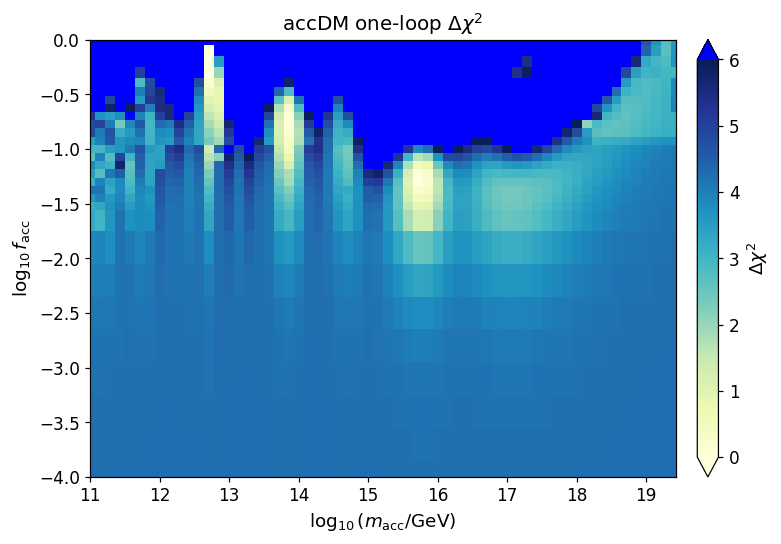

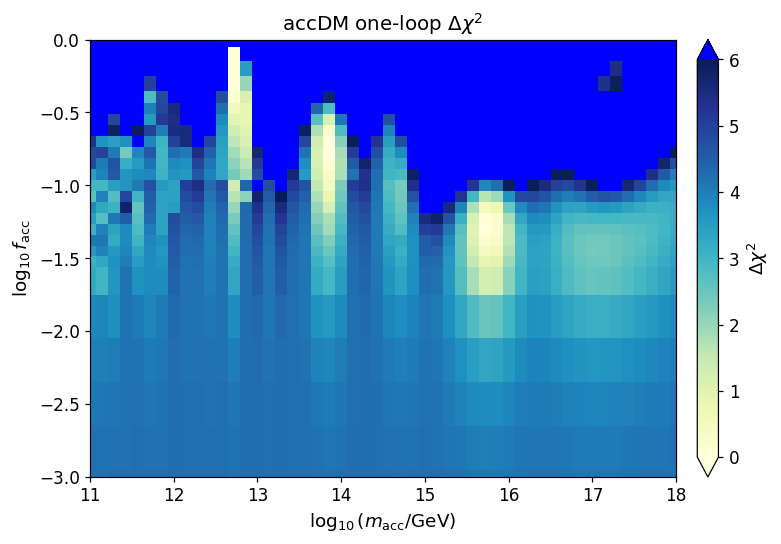

In [20]:
def cell_edges(values):
    values = np.asarray(values, float)
    if len(values) < 2 or not np.all(np.diff(values) > 0):
        raise ValueError("Plot coordinates must be strictly increasing.")
    mid = (values[:-1]+values[1:])/2
    return np.r_[values[0]-(mid[0]-values[0]), mid, values[-1]+(values[-1]-mid[-1])]


mass_edges, fraction_edges = cell_edges(x_grid), cell_edges(y_grid)
plot_xlim = (float(x_grid[0]), float(x_grid[-1])) if PLOT_XLIM is None else PLOT_XLIM
plot_ylim = (float(y_grid[0]), float(y_grid[-1])) if PLOT_YLIM is None else PLOT_YLIM
colourmap = plt.get_cmap("YlGnBu").copy()
colourmap.set_over("#0000ff")
colourmap.set_under(colourmap(0.0))
colourmap.set_bad("#eeeeee")
colour_norm = Normalize(0.0, DISPLAY_DELTA_MAX, clip=False)


def save_figure(fig, stem):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            fig.savefig(OUTPUT_DIR/f"{stem}.{extension}", dpi=250, bbox_inches="tight")


def draw_native_map(ax, values, xlim, ylim, title=None, annotate=True):
    values = np.asarray(values, float)
    if PLOT_STYLE == "bilinear":
        mx = np.linspace(x_grid[0], x_grid[-1], PLOT_RESOLUTION[0])
        fy = np.linspace(y_grid[0], y_grid[-1], PLOT_RESOLUTION[1])
        mm, ff = np.meshgrid(mx, fy)
        interpolator = RegularGridInterpolator((y_grid, x_grid), values,
                                               bounds_error=False, fill_value=np.nan)
        z = interp_native(interpolator, mm, ff)
        artist = ax.pcolormesh(mx, fy, np.ma.masked_invalid(z), shading="nearest",
                              cmap=colourmap, norm=colour_norm, rasterized=True)
    else:
        artist = ax.pcolormesh(mass_edges, fraction_edges, np.ma.masked_invalid(values),
                              shading="flat", cmap=colourmap, norm=colour_norm, rasterized=True)
    if annotate and SHOW_ESTIMATE_HATCH:
        for i, j in np.argwhere(estimate_mask):
            ax.add_patch(Rectangle((mass_edges[j], fraction_edges[i]),
                mass_edges[j+1]-mass_edges[j], fraction_edges[i+1]-fraction_edges[i],
                fill=False, hatch="..", edgecolor="#666666", linewidth=0, alpha=.45))
    if annotate and SHOW_CORNER_BOUNDARY and corner_mask.any():
        ax.plot([ORIGINAL_MAX_LOGM, ORIGINAL_MAX_LOGM, x_grid[-1]],
                [y_grid[-1], TRANSITION_LOGF, TRANSITION_LOGF],
                color="white", ls=":", lw=.9)
    ax.set(xlim=xlim, ylim=ylim, xlabel=r"$\log_{10}(m_{\rm acc}/{\rm GeV})$",
           ylabel=r"$\log_{10}f_{\rm acc}$", title=title)
    ax.set_facecolor("#eeeeee")
    ax.tick_params(direction="out", length=3)
    return artist


def create_main_figure(xlim, ylim, stem):
    fig, ax = plt.subplots(figsize=(7.4, 5.6))
    fig.subplots_adjust(left=.12, right=.84, top=.90, bottom=.19)
    artist = draw_native_map(ax, completed_delta_grid, xlim, ylim,
                            title=r"accDM one-loop $\Delta\chi^2$")
    cax = fig.add_axes([.866, .19, .026, .71])
    extension = "both" if np.any(completed_delta_grid < 0) else "max"
    fig.colorbar(artist, cax=cax, extend=extension,
                 ticks=np.arange(0, DISPLAY_DELTA_MAX+1e-9, 1), label=r"$\Delta\chi^2$")
    # note = (r"Includes estimated cells; $\Delta\chi^2=\chi^2-\chi^2_{\rm ref}$, "
    #         + rf"$\chi^2_{{\rm ref}}={REFERENCE_CHI2:.4f}$.")
    # fig.text(.49, .052, note, ha="center", va="center", fontsize=8.5, color="#444444")
    save_figure(fig, stem)
    plt.show()
    return fig


fig_full = create_main_figure(plot_xlim, plot_ylim, "accdm_mass_fraction_full")
if SAVE_LEGACY_CROP:
    fig_legacy = create_main_figure(LEGACY_XLIM, LEGACY_YLIM, "accdm_mass_fraction_legacy_crop")


## 8. Pochodzenie wartości i sprawdzenie scenariusza

Mapa pochodzenia obejmuje także surowe fity odrzucone z puli kotwic prognozy
przez diagnostykę optymalizatora. **To nie usuwa ich z mapy χ².**
Tabela poniżej porównuje czysty scenariusz z ukończonymi fitami rozszerzenia;
jest diagnostyką zgodności, nie niezależnym testem fizycznego założenia.
Nie wyznaczamy z niej błędu statystycznego dla brakującego rogu.


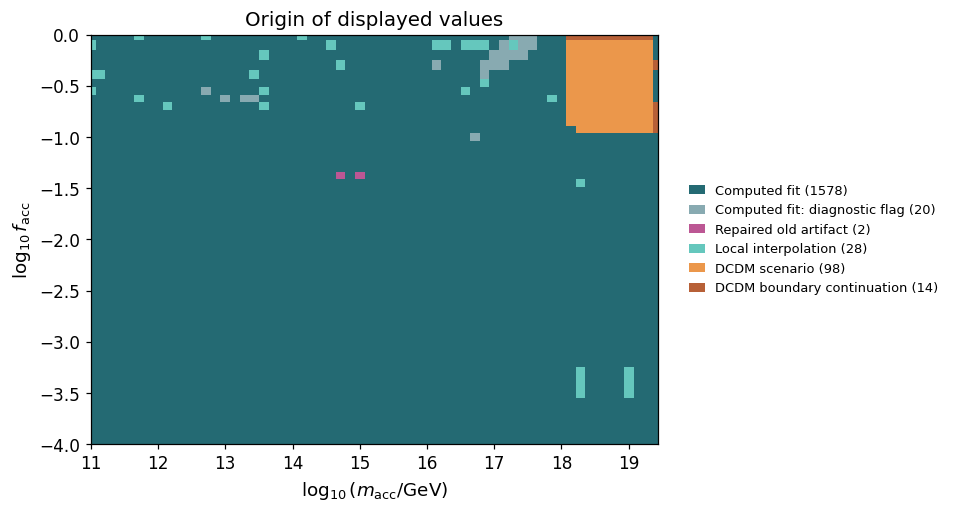

,log10m_acc,log10f_acc,raw_chi2,scenario_chi2,trusted_anchor_diagnostics,scenario_minus_computed
0,18.142857,-0.925,192.669265,192.383330,True,-0.285935
1,19.428571,-0.625,192.922859,192.099387,True,-0.823472
2,19.428571,-0.550,192.882927,192.081451,True,-0.801475
3,19.428571,-0.475,192.840675,192.054929,True,-0.785746
4,19.428571,-0.400,192.796701,192.016106,True,-0.780595
5,19.428571,-0.200,192.677322,191.818548,True,-0.858773
6,19.428571,-0.100,192.620682,191.635048,True,-0.985633
7,19.428571,0.000,192.568988,191.603020,True,-0.965968


Corner scenario MAE (diagnostic): 0.7859496560016268
Shift variants are scenarios, not a statistical uncertainty interval.


,variant,query_shift,forecast_cells,max_abs_delta_change,boundary_hold_cells
0,minus,0.712082,112,5.976007,14
1,central,0.912082,112,0.000000,14
2,plus,1.112082,112,5.983250,23


In [ ]:
PROVENANCE = [
    ("computed_fit", "Computed fit", "#246a73"),
    ("computed_fit_flagged", "Computed fit: diagnostic flag", "#88aab1"),
    ("repaired_old_artifact", "Repaired old artifact", "#bc5794"),
    ("local_interpolation", "Local interpolation", "#65c7bd"),
    ("local_boundary_hold", "Local boundary continuation", "#dec364"),
    ("dcdm_shape_forecast", "DCDM scenario", "#eb974b"),
    ("template_boundary_hold", "DCDM boundary continuation", "#b76037"),
    ("local_corner_fallback", "Local fallback in the corner", "#9168ab"),
    ("unsupported", "No estimate", "#eeeeee"),
]
provenance_codes = np.full(provenance_grid.shape, -1, dtype=int)
for index, (key, label, color) in enumerate(PROVENANCE):
    provenance_codes[provenance_grid == key] = index
assert (provenance_codes >= 0).all()
fig_sources, ax = plt.subplots(figsize=(9.2, 5.1))
fig_sources.subplots_adjust(left=.10, right=.66, top=.89, bottom=.16)
ax.pcolormesh(mass_edges, fraction_edges, provenance_codes, shading="flat",
              cmap=ListedColormap([p[2] for p in PROVENANCE]),
              norm=BoundaryNorm(np.arange(len(PROVENANCE)+1)-.5, len(PROVENANCE)),
              rasterized=True)
ax.set(xlim=plot_xlim, ylim=plot_ylim, title="Origin of displayed values",
       xlabel=r"$\log_{10}(m_{\rm acc}/{\rm GeV})$", ylabel=r"$\log_{10}f_{\rm acc}$")
handles = [Patch(facecolor=color, label=f"{label} ({np.sum(provenance_grid == key)})")
           for key, label, color in PROVENANCE if np.any(provenance_grid == key)]
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.035, .5),
          frameon=False, fontsize=8.5, handlelength=1.2)
save_figure(fig_sources, "accdm_mass_fraction_provenance")
plt.show()

checks = corner_mask & measured_mask & np.isfinite(conditional_delta_grid)
corner_check = pd.DataFrame({
    "log10m_acc": native_m[checks], "log10f_acc": native_f[checks],
    "raw_chi2": chi_raw_grid[checks],
    "scenario_chi2": conditional_delta_grid[checks]+REFERENCE_CHI2,
    "trusted_anchor_diagnostics": trusted_mask_grid[checks],
})
corner_check["scenario_minus_computed"] = corner_check.scenario_chi2-corner_check.raw_chi2
if len(corner_check):
    display(corner_check)
    print("Corner scenario MAE (diagnostic):", corner_check.scenario_minus_computed.abs().mean())
else:
    print("No completed corner fits available for the scenario comparison.")

sensitivity_rows = []
sensitivity_grids = {}
if RUN_SHIFT_SENSITIVITY:
    for tag, displacement in [("minus", -SHIFT_SENSITIVITY_DEX), ("central", 0.),
                              ("plus", SHIFT_SENSITIVITY_DEX)]:
        values, _, _, _, kinds, mask = complete_map(SHIFT+displacement)
        sensitivity_grids[tag] = values
        residual = values[mask]-completed_delta_grid[mask]
        sensitivity_rows.append({
            "variant": tag, "query_shift": SHIFT+displacement,
            "forecast_cells": int(mask.sum()),
            "max_abs_delta_change": float(np.nanmax(np.abs(residual))) if mask.any() else 0.,
            "boundary_hold_cells": int(np.sum(kinds == "template_boundary_hold")),
        })
        assert np.allclose(values[measured_mask], completed_delta_grid[measured_mask], equal_nan=True)
    print("Shift variants are scenarios, not a statistical uncertainty interval.")
    display(pd.DataFrame(sensitivity_rows))
    if SHOW_SHIFT_SENSITIVITY:
        fig_sensitivity, axes = plt.subplots(1, 3, figsize=(14.0, 4.2), sharex=True, sharey=True)
        fig_sensitivity.subplots_adjust(left=.06, right=.90, bottom=.22, top=.86, wspace=.15)
        for ax, item in zip(axes, sensitivity_rows):
            artist = draw_native_map(ax, sensitivity_grids[item["variant"]], plot_xlim, plot_ylim,
                                      title=f"query shift = {item['query_shift']:+.3f}", annotate=False)
        for ax in axes[1:]:
            ax.set_ylabel("")
        cax = fig_sensitivity.add_axes([.92, .22, .015, .64])
        fig_sensitivity.colorbar(artist, cax=cax, extend="max", label=r"$\Delta\chi^2$")
        fig_sensitivity.text(.5, .055, "Selected scenarios, not confidence intervals.",
                             ha="center", fontsize=9)
        save_figure(fig_sensitivity, "accdm_mass_fraction_shift_sensitivity")
        plt.show()


## 9. Eksport i kontrola zachowania surowych danych

`accdm_mass_fraction_completed.csv` zawiera surowe χ², χ² wyświetlane, Δχ²,
scenariusz DCDM, maski i pochodzenie komórki. `raw_chi2` jest puste tam, gdzie
fit się nie zakończył. Kolumna `planned_grid_point` rozróżnia manifest od
uzupełniającego iloczynu osi, gdy siatka nie jest prostokątna.

PNG/PDF służą do prezentacji; CSV/NPZ zachowują pełną skalę liczbową — bez
obcinania do 0–6. Metadane utrwalają wejścia użyte w danym uruchomieniu,
ustawienia i punkt odniesienia. Zachowaj dany eksport, jeśli chcesz porównać
dzisiejszą prognozę z przyszłymi fitami.


In [ ]:
audit = pd.DataFrame({
    "log10m_acc": native_m.ravel(), "log10f_acc": native_f.ravel(),
    "log10_epsilon_eff": native_e.ravel(), "log10_gamma_eff": native_g.ravel(),
    "raw_chi2": chi_raw_grid.ravel(),
    "display_chi2": (completed_delta_grid+REFERENCE_CHI2).ravel(),
    "delta_chi2": completed_delta_grid.ravel(),
    "conditional_scenario_chi2": (conditional_delta_grid+REFERENCE_CHI2).ravel(),
    "provenance": provenance_grid.ravel(),
    "has_completed_fit": np.isfinite(chi_raw_grid).ravel(),
    "is_retained_computed_value": measured_mask.ravel(),
    "is_estimated_display_value": estimate_mask.ravel(),
    "is_missing_corner_forecast": forecast_grid.ravel(),
    "trusted_for_forecast": trusted_mask_grid.ravel(),
    "inside_native_dcdm_support_after_shift": template_supported_grid.ravel(),
})
audit["coordinate_key"] = [coordinate_key(m, f) for m, f in zip(audit.log10m_acc, audit.log10f_acc)]
audit["planned_grid_point"] = audit.coordinate_key.isin(set(expected_points.coordinate_key))
source_columns = [c for c in ["coordinate_key", "point_id", "source_label", "source_directory",
                              "momentum_bins", "optimizer_success", "minimum_bound_distance"]
                  if c in sampled.columns]
audit = audit.merge(sampled[source_columns], on="coordinate_key", how="left", validate="one_to_one")

unchanged = audit.is_retained_computed_value
assert np.allclose(audit.loc[unchanged, "raw_chi2"], audit.loc[unchanged, "display_chi2"],
                   rtol=0, atol=1e-10)
assert not (audit.has_completed_fit & audit.is_missing_corner_forecast).any()
assert np.isfinite(audit.loc[audit.has_completed_fit, "raw_chi2"]).all()

metadata = {
    "purpose": "native accDM mass-fraction map; missing cells are conditional estimates, not fits",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "reference_chi2_accdm": REFERENCE_CHI2,
    "reference_method": REFERENCE_METHOD,
    "reference_chi2_dcdm": float(dcdm.chi2.min()),
    "stable_logepsilon_window": list(STABLE_LOGEPS_WINDOW),
    "base_csv": str(base_sampled_path), "base_csv_sha256": sha256_file(base_sampled_path),
    "dcdm_csv": str(DCDM_PROFILE_CSV), "dcdm_csv_sha256": DCDM_FILE_HASH,
    "campaigns": [{"label": s["label"], "directory": str(s["directory"]),
                   "manifest_sha256": sha256_file(Path(s["directory"])/"manifest.csv")}
                  for s in EXTENSION_CAMPAIGNS],
    "completed_input_sha256": hashlib.sha256(sampled.sort_values("coordinate_key")[[
        "coordinate_key", "chi2_one_loop", "source_label"]].to_csv(index=False).encode()).hexdigest(),
    "completed_fit_count": int(np.isfinite(chi_raw_grid).sum()),
    "retained_computed_count": int(measured_mask.sum()),
    "reference_uses_forecast_values": False,
    "provenance_counts": {str(k): int(v) for k, v in pd.Series(provenance_grid.ravel()).value_counts().items()},
    "query_shift": SHIFT, "displayed_loggamma_shift": -SHIFT, "shift_method": SHIFT_METHOD,
    "template_amplitude": TEMPLATE_AMPLITUDE, "template_offset": TEMPLATE_OFFSET,
    "eps_blend_dex": EPS_BLEND_DEX, "gamma_blend_dex": GAMMA_BLEND_DEX,
    "gamma_outside_policy": TEMPLATE_GAMMA_OUTSIDE,
    "epsilon_outside_policy": TEMPLATE_EPSILON_OUTSIDE,
    "unsupported_corner_policy": UNSUPPORTED_CORNER_POLICY,
    "local_gap_method": "piecewise linear within each fraction band; nearest anchor outside convex hull",
    "repair_enabled": REPAIR_KNOWN_OUTLIERS,
    "repair_guard": "only replace known raw artifact values within match tolerance",
    "actually_repaired_keys": sorted(configured_repair_keys),
    "sensitivity_is_confidence_interval": False,
    "negative_delta_cells": int(np.sum(completed_delta_grid < 0)),
    "plot_style": PLOT_STYLE, "colour_limits": [0.0, DISPLAY_DELTA_MAX],
    "over_colour": "#0000ff", "plot_xlim": list(plot_xlim), "plot_ylim": list(plot_ylim),
    "legacy_xlim": list(LEGACY_XLIM), "legacy_ylim": list(LEGACY_YLIM),
    "f_one_policy": "native log10f=0; DCDM template Gamma boundary continuation when configured",
}

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    audit.to_csv(OUTPUT_DIR/"accdm_mass_fraction_completed.csv", index=False)
    sampled.to_csv(OUTPUT_DIR/"accdm_computed_input_snapshot.csv", index=False)
    dcdm[["log10_gamma", "log10_epsilon", "chi2"]].to_csv(
        OUTPUT_DIR/"dcdm_input_snapshot.csv", index=False)
    corner_check.to_csv(OUTPUT_DIR/"corner_scenario_check.csv", index=False)
    shift_calibration.to_csv(OUTPUT_DIR/"shift_calibration.csv", index=False)
    repair_audit.to_csv(OUTPUT_DIR/"known_outlier_repairs.csv", index=False)
    pd.DataFrame(sensitivity_rows).to_csv(OUTPUT_DIR/"shift_sensitivity.csv", index=False)
    np.savez_compressed(OUTPUT_DIR/"accdm_mass_fraction_grid.npz",
        log10m=x_grid, log10f=y_grid, raw_chi2=chi_raw_grid,
        display_chi2=completed_delta_grid+REFERENCE_CHI2,
        delta_chi2=completed_delta_grid, conditional_delta=conditional_delta_grid,
        reference_chi2=np.array(REFERENCE_CHI2),
        provenance=provenance_grid.astype(str), forecast_mask=forecast_grid,
        retained_fit_mask=measured_mask, estimated_mask=estimate_mask,
        **{f"delta_shift_{key}": value for key, value in sensitivity_grids.items()})
    (OUTPUT_DIR/"accdm_mass_fraction_metadata.json").write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False, allow_nan=False)+"\n", encoding="utf-8")
    print("Saved figures, numerical grid and metadata:", OUTPUT_DIR)
print("OK: retained fits unchanged; forecast values do not set the reference.")


Saved figures, numerical grid and metadata: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_mass_fraction_completed_v1
OK: retained fits unchanged; forecast values do not set the reference.
